# 🔍 Notatbok 02 — Undersøk åstedet

**Globale forklaringer — forstå hvordan modellen tenker overordnet.**

I forrige notatbok møtte vi to mysterier: Karis krav ble avslått til tross for
en ren profil, og Eriks krav ble godkjent til tross for en risikoprofil. Før vi
zoomer inn på deres spesifikke saker, la oss **undersøke hele åstedet** —
hvordan tar modellen beslutninger *generelt*?

Dette er forskjellen mellom **globale** og **lokale** forklaringer:
- **Globalt** = «Hvilke mønstre bruker modellen på tvers av alle prediksjoner?»
- **Lokalt** = «Hvorfor ga modellen *denne* spesifikke prediksjonen?»

*Analogi: undersøk hele åstedet før du fokuserer på spesifikke spor.*

### Verktøy i denne notatboken

| Verktøy | Spørsmålet det besvarer |
|---------|------------------------|
| Permutation Importance | Hvilke egenskaper betyr mest totalt? |
| PDP / ICE-plott | Hvordan påvirker endring i én egenskap prediksjonene? |
| SHAP oppsummering/stolpe | Hvordan bidrar egenskapene på tvers av alle prediksjoner? |

## 0. Setup

In [703]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %pip install -q pandas numpy scikit-learn xgboost matplotlib seaborn shap lime dice-ml ipywidgets

In [704]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import pickle
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("✅ Alle importer lastet inn.")

✅ Alle importer lastet inn.


In [705]:
load_path = "nb01_artifacts.pkl" if IN_COLAB else "../data/nb01_artifacts.pkl"
with open(load_path, "rb") as f:
    arts = pickle.load(f)
model = arts["model"]
X_train, X_test = arts["X_train"], arts["X_test"]
y_train, y_test = arts["y_train"], arts["y_test"]
feature_cols = arts["feature_cols"]
df = arts["df"]
df_model = arts["df_model"]
X, y = arts["X"], arts["y"]
print("✅ Artefakter lastet inn.")

✅ Artefakter lastet inn.


## 1. Permutation Importance

**Konsept:** Stokk verdiene til én egenskap tilfeldig, og mål deretter hvor mye
modellens nøyaktighet synker. Stor nedgang → viktig egenskap.

Denne metoden er:
- **Modellagnostisk** — fungerer med enhver modell
- **Enkel å forstå** — «hvor mye lider nøyaktigheten uten denne egenskapen?»
- **Basert på testsettet** — måler reell prediktiv viktighet

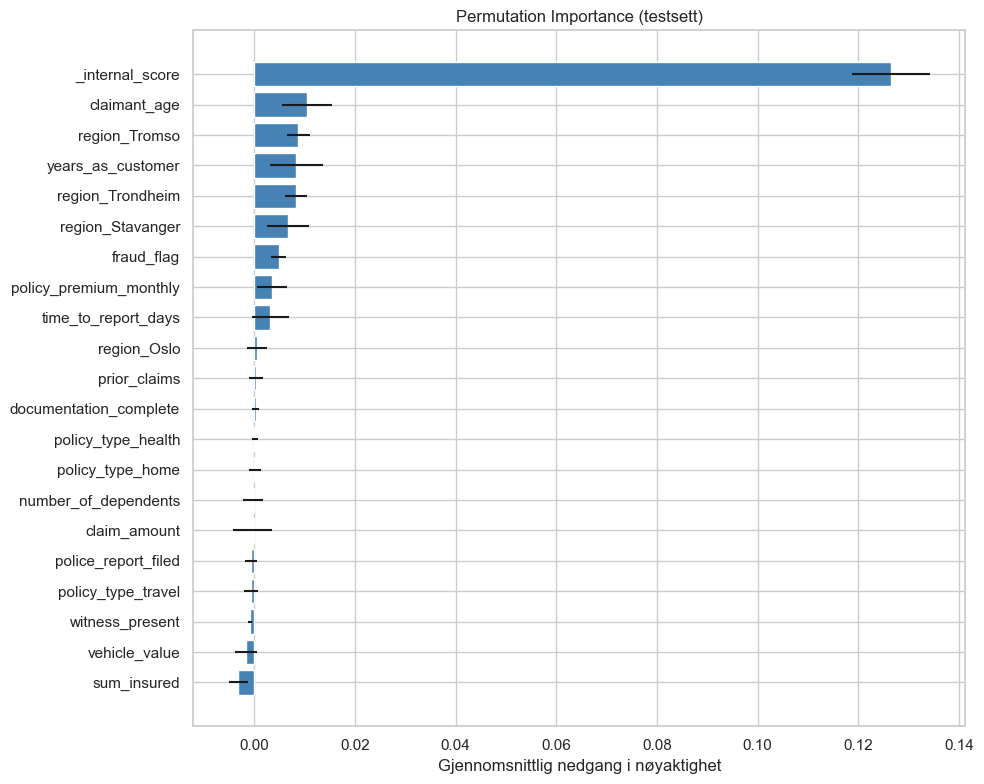

In [706]:
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(perm_df["feature"], perm_df["importance_mean"], xerr=perm_df["importance_std"], color="steelblue")
ax.set_xlabel("Gjennomsnittlig nedgang i nøyaktighet")
ax.set_title("Permutation Importance (testsett)")
plt.tight_layout()
plt.show()

### 💬 Diskusjon

- Er det noe som ser **mistenkelig dominerende** ut?

## 2. Partial Dependence og ICE-plott

**PDP** (Partial Dependence Plot) viser den **gjennomsnittlige** effekten av én
egenskap på prediksjonen, mens alle andre egenskaper holdes på sine faktiske verdier.

**ICE** (Individual Conditional Expectation) viser effekten for **hvert enkelt**
datapunkt — hver linje er én person.

PDP er **gjennomsnittet** av alle ICE-linjene.

> **Mental modell:** PDP forteller deg det *gjennomsnittlige* forholdet. ICE forteller
> deg om det forholdet er *konsistent* på tvers av individer.

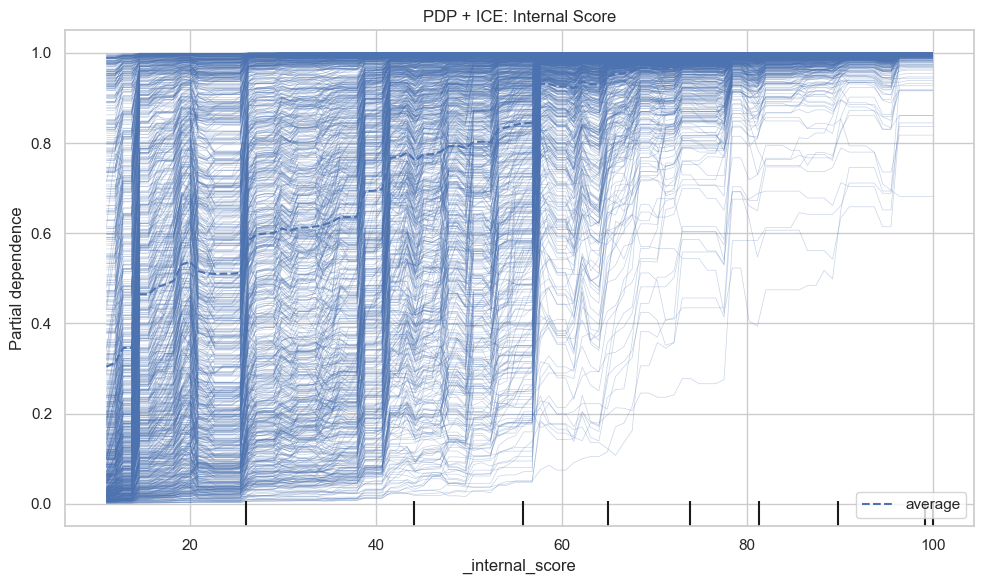

In [707]:
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(model, X_test, ["_internal_score"], ax=ax, kind="both")
ax.set_title("PDP + ICE: Internal Score")
plt.tight_layout()
plt.show()

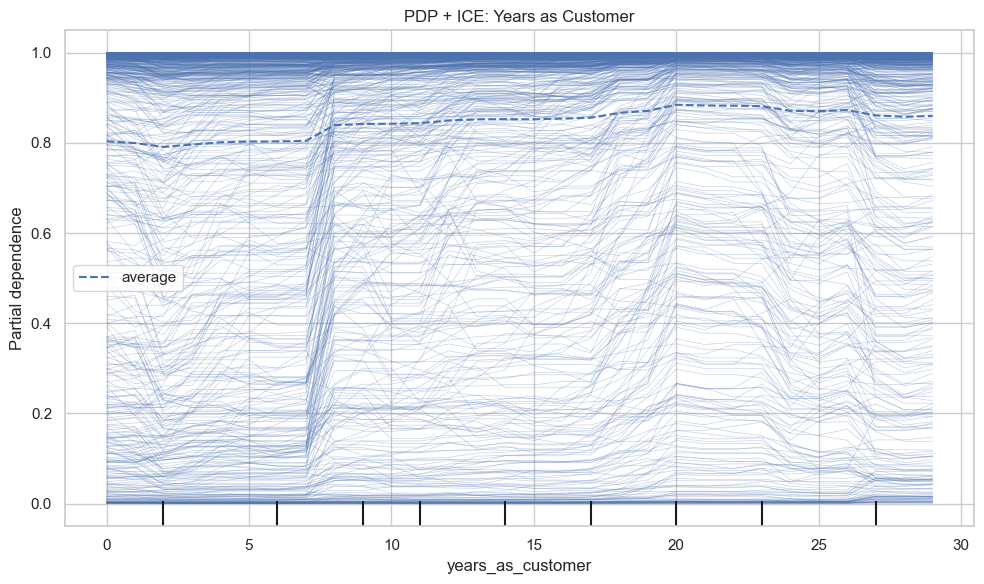

In [708]:
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(model, X_test, ["years_as_customer"], ax=ax, kind="both")
ax.set_title("PDP + ICE: Years as Customer")
plt.tight_layout()
plt.show()

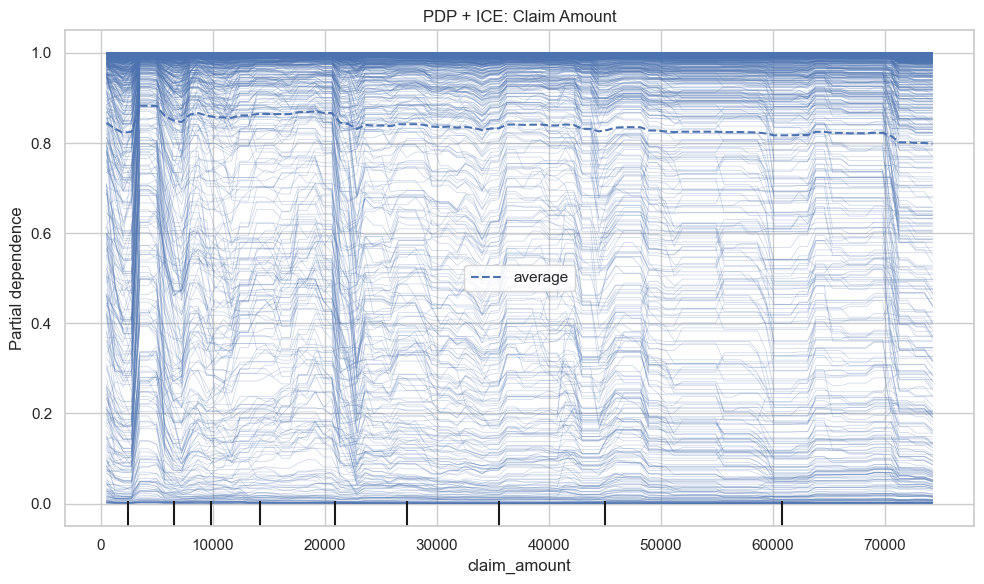

In [709]:
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(model, X_test, ["claim_amount"], ax=ax, kind="both")
ax.set_title("PDP + ICE: Claim Amount")
plt.tight_layout()
plt.show()

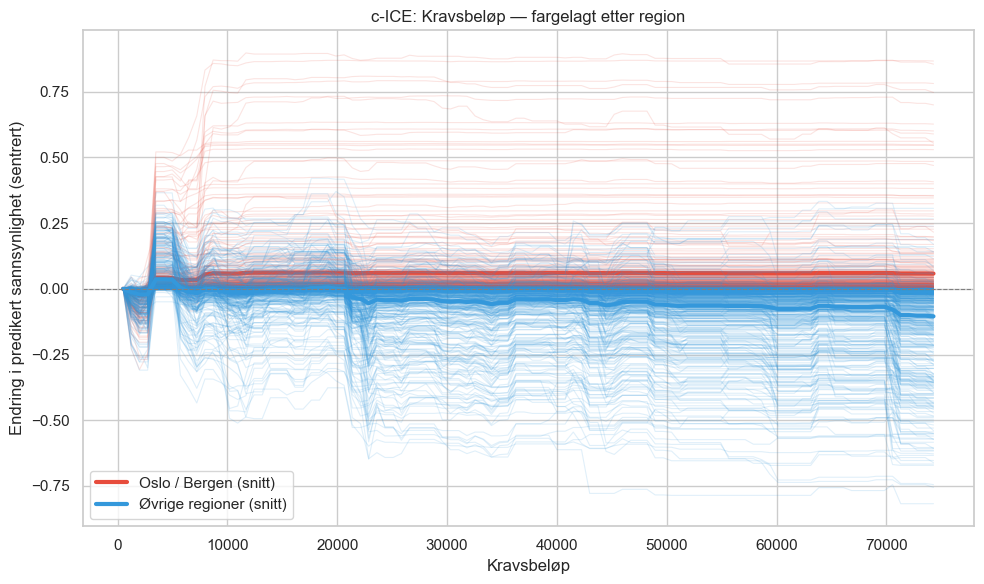

In [710]:
# ICE-plott for claim_amount, fargelagt etter region
from sklearn.inspection import partial_dependence

feature_idx = feature_cols.index("claim_amount")
ice_result = partial_dependence(model, X_test, [feature_idx], kind="individual")
grid_values = ice_result["grid_values"][0] if "grid_values" in ice_result else ice_result["values"][0]
individual = ice_result["individual"][0]

# Sentrer (c-ICE) slik at alle linjer starter på 0
centered = individual - individual[:, [0]]

fig, ax = plt.subplots(figsize=(10, 6))

premium_mask = df.loc[X_test.index, "region"].isin(["Oslo", "Bergen"]).values
colors_ice = {True: "#e74c3c", False: "#3498db"}
labels_ice = {True: "Oslo / Bergen", False: "Øvrige regioner"}

for is_premium in [True, False]:
    mask = premium_mask == is_premium
    for i in np.where(mask)[0]:
        ax.plot(grid_values, centered[i], alpha=0.15, color=colors_ice[is_premium], linewidth=0.8)
    group_mean = centered[mask].mean(axis=0)
    ax.plot(grid_values, group_mean, color=colors_ice[is_premium],
            linewidth=3, label=f"{labels_ice[is_premium]} (snitt)")

ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("Kravsbeløp")
ax.set_ylabel("Endring i predikert sannsynlighet (sentrert)")
ax.set_title("c-ICE: Kravsbeløp — fargelagt etter region")
ax.legend()
plt.tight_layout()
plt.show()

### 🤔 Hmm ... ikke så mye å se?

ICE-plottet ser ganske flatt ut. Det er fordi `_internal_score` dominerer modellen
så sterkt at `claim_amount` knapt påvirker prediksjonen. Men betyr det at
kravsbeløp *egentlig* ikke har noe å si? La oss sjekke **rådataene** direkte:

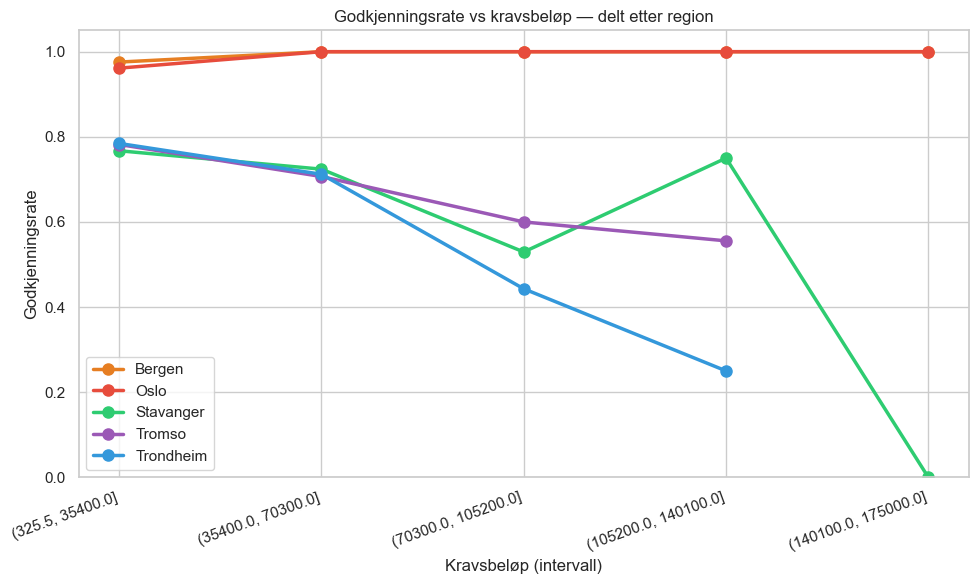

In [711]:
# Godkjenningsrate per kravsbeløp-intervall, delt etter region
# Før vi stoler på modellens forklaringer, la oss se på RÅDATAENE.

plot_df = df.copy()
plot_df["claim_bin"] = pd.cut(plot_df["claim_amount"], bins=5)

approval_by_bin = (plot_df.groupby(["claim_bin", "region"], observed=True)["approved"]
                   .mean().reset_index())

fig, ax = plt.subplots(figsize=(10, 6))
colors = {"Oslo": "#e74c3c", "Bergen": "#e67e22", "Trondheim": "#3498db",
          "Stavanger": "#2ecc71", "Tromso": "#9b59b6"}
for region, grp in approval_by_bin.groupby("region"):
    x = range(len(grp))
    ax.plot(x, grp["approved"].values, marker="o", linewidth=2.5,
            color=colors.get(region, "grey"), label=region, markersize=8)

ax.set_xticks(range(len(approval_by_bin["claim_bin"].unique())))
ax.set_xticklabels([str(b) for b in approval_by_bin["claim_bin"].unique()], rotation=20, ha="right")
ax.set_xlabel("Kravsbeløp (intervall)")
ax.set_ylabel("Godkjenningsrate")
ax.set_title("Godkjenningsrate vs kravsbeløp — delt etter region")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### 🔍 Legg merke til noe merkelig?

Se på hvordan linjene beveger seg. Er det noe merkelig her?

## 🏋️ Øvelse 2: Lag ditt eget PDP-plott

Velg en egenskap og lag et PDP/ICE-plott. Hva forteller det deg?

In [712]:
# ØVELSE: Velg en egenskap fra listen og lag et PDP/ICE-plott
# Tilgjengelige egenskaper: print(feature_cols) for å se alle
# Hint: bruk PartialDependenceDisplay.from_estimator(model, X_test, ["din_egenskap"])

# DIN KODE HER

## 3. SHAP globale plott

**SHAP** (SHapley Additive exPlanations) er basert på **Shapley-verdier** fra
kooperativ spillteori. Ideen: hver egenskap får en rettferdig «utbetaling» for
sitt bidrag til hver prediksjon.

For en **global** oversikt aggregerer vi SHAP-verdier på tvers av alle prediksjoner:

- **Stolpediagram:** Gjennomsnittlig |SHAP-verdi| per egenskap — hvilke betyr mest i snitt
- **Beeswarm / oppsummeringsplott:** Viser *fordelingen* av SHAP-verdier per egenskap —
  hvordan egenskapsverdier (høy/lav) relaterer seg til påvirkningsretningen

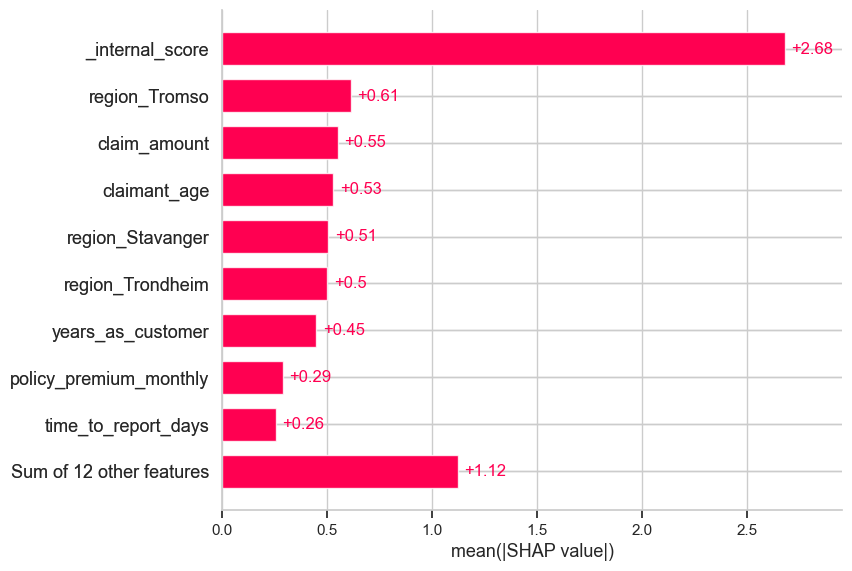

In [713]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
shap.plots.bar(shap_values)

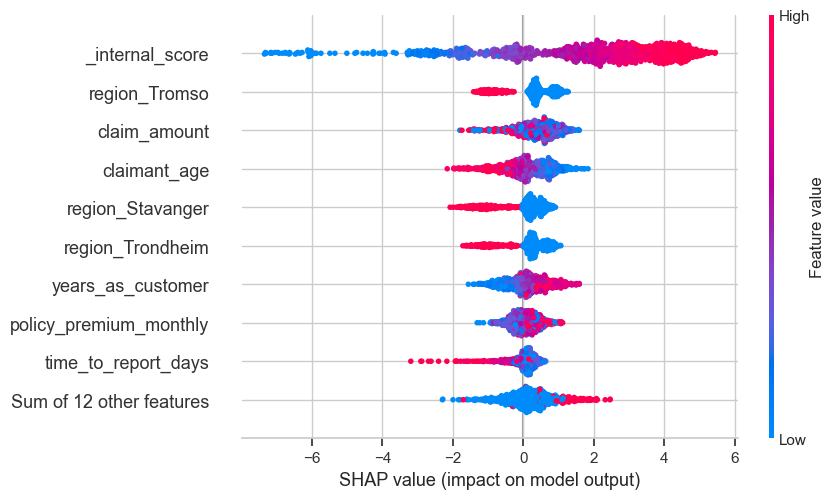

In [714]:
shap.plots.beeswarm(shap_values)

## 🏋️ Øvelse 3: Tolk SHAP-oppsummeringen

Skriv en briefing på **3 setninger** for forsikringssjefen som forklarer hva
SHAP-plottene avslører om modellens beslutningstaking.

In [715]:
# ØVELSE: Skriv et sammendrag på 3 setninger for forsikringssjefen
# Basert på SHAP-plottene ovenfor, forklar:
#   1. Hva er de 3 mest innflytelsesrike egenskapene?
#   2. Hvordan påvirker de beslutningen (positiv/negativ retning)?
#   3. Er det noe overraskende eller bekymringsfullt?
#
# DITT SAMMENDRAG:
# """
# Kjære forsikringssjef,
#
# [Ditt sammendrag her]
#
# """

## 🔑 Mental modell: Globale forklaringer

| Metode | Spørsmål | Fordeler | Ulemper |
|--------|----------|----------|--------|
| Permutation Importance | Hvilke egenskaper betyr noe? | Enkel, modellagnostisk | Påvirkes av korrelerte egenskaper |
| PDP / ICE | Hvordan påvirker én egenskap prediksjonene? | Visuell, intuitiv | Antar egenskapsuavhengighet |
| SHAP (global) | Hvordan bidrar egenskapene totalt? | Teoretisk forankret, retningsbestemt | Beregningskrevende |

Disse metodene forteller oss om modellen **overordnet**, men **ikke** om
spesifikke beslutninger. For det trenger vi **lokale** forklaringer — neste notatbok.

👉 **Neste:** [Notatbok 03 — Avhør av mistenkte](03_local_explanations.ipynb)

In [716]:
# Lagre SHAP-verdier til bruk i senere notatbøker
arts["shap_values_test"] = shap_values
save_path = "nb01_artifacts.pkl" if IN_COLAB else "../data/nb01_artifacts.pkl"
with open(save_path, "wb") as f:
    pickle.dump(arts, f)
print("✅ SHAP-verdier lagret.")

✅ SHAP-verdier lagret.
